#Check the assigned GPU and basic understanding of drive with dataset

In [ ]:
!nvidia-smi

Tue Apr 14 13:09:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#Mounting google drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

os.listdir('/content/drive/MyDrive')

base_path = '/content/drive/MyDrive/Dataset'
os.listdir(base_path)


['val', 'train', 'test', 'data.yaml']

In [3]:
os.listdir(base_path + '/train')
os.listdir(base_path + '/train/images')[:5]
os.listdir(base_path + '/train/labels')[:5]

['48_1202_bmp.rf.04372435bcbdf7e2e77f404f85478b24.txt',
 '379_JPG.rf.104b1dbd32c52afdabc0359c520e4888.txt',
 '45_JPG.rf.19254171bcdc4864ba4d616cd0053bed.txt',
 '43_jpg.rf.6a6116c22555c1f2bd545ad08ca02131.txt',
 '50_jpg.rf.dd22fa2d9f4ddd9237aca13f4fe000a6.txt']

In [4]:
import os

train_count = len(os.listdir('/content/drive/MyDrive/Dataset/train/images'))
val_count = len(os.listdir('/content/drive/MyDrive/Dataset/val/images'))
test_count = len(os.listdir('/content/drive/MyDrive/Dataset/test/images'))

print("Train:", train_count)
print("Validation:", val_count)
print("Test:", test_count)
print("Total:", train_count + val_count + test_count)

Train: 2235
Validation: 80
Test: 41
Total: 2356


#Inspecting data.yaml made accurately

In [ ]:
with open(base_path + '/data.yaml', 'r') as f:
    print(f.read())


names:
- Crown
- Dental_Fillings
- Endodontic_post
- Root_Canal_treated_tooth
- bridge
- implant
nc: 6
path: /content/drive/MyDrive/Dataset
test: test/images
train: train/images
val: val/images


#Dataset Characterization Cell


Dataset Class Distribution:



,Dental Treatment,Number of Instances
0,Crown,1541
1,Dental_Fillings,5881
2,Endodontic_post,632
3,Root_Canal_treated_tooth,1400
4,Bridge,604
5,Implant,838


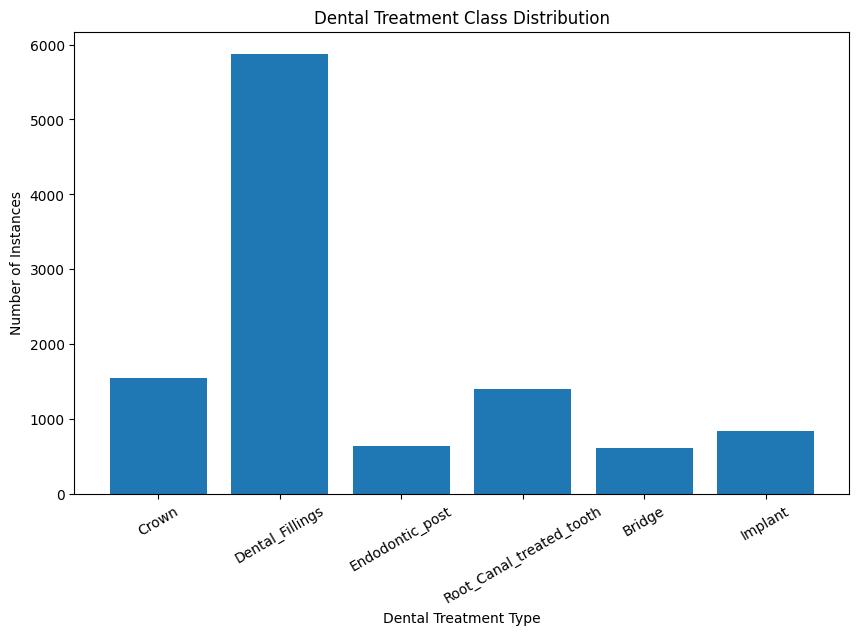

Chart saved to: /content/drive/MyDrive/DentalXNet-Det/experiments/dataset_class_distribution.png


In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

LABEL_PATH = "/content/drive/MyDrive/Dataset/train/labels"
SAVE_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments"

os.makedirs(SAVE_PATH, exist_ok=True)

class_names = [
    "Crown",
    "Dental_Fillings",
    "Endodontic_post",
    "Root_Canal_treated_tooth",
    "Bridge",
    "Implant"
]

class_counts = Counter()

for label_file in os.listdir(LABEL_PATH):
    if label_file.endswith(".txt"):
        with open(os.path.join(LABEL_PATH, label_file)) as f:
            for line in f.readlines():
                class_id = int(line.split()[0])
                class_counts[class_id] += 1

counts = [class_counts[i] for i in range(len(class_names))]

# ---------- Create Table ----------
df = pd.DataFrame({
    "Dental Treatment": class_names,
    "Number of Instances": counts
})

print("\nDataset Class Distribution:\n")
display(df)

# ---------- Plot Chart ----------
plt.figure(figsize=(10,6))
plt.bar(class_names, counts)

plt.title("Dental Treatment Class Distribution")
plt.xlabel("Dental Treatment Type")
plt.ylabel("Number of Instances")
plt.xticks(rotation=30)

save_file = os.path.join(SAVE_PATH, "dataset_class_distribution.png")
plt.savefig(save_file, bbox_inches="tight")

plt.show()

print("Chart saved to:", save_file)

#Training

In [ ]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.9 MB/s eta 0:00:00


#Inspecting data.yaml made accurately

In [ ]:
import yaml

yaml_path = '/content/drive/MyDrive/Dataset/data.yaml'

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Update base path for Colab
data['path'] = '/content/drive/MyDrive/Dataset'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("Updated data.yaml content:\n")
print(data)


Updated data.yaml content:

{'names': ['Crown', 'Dental_Fillings', 'Endodontic_post', 'Root_Canal_treated_tooth', 'bridge', 'implant'], 'nc': 6, 'path': '/content/drive/MyDrive/Dataset', 'test': 'test/images', 'train': 'train/images', 'val': 'val/images'}


#model loading

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
print("YOLO model loaded successfully")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO model loaded successfully


In [ ]:
#Not needed to execute
from ultralytics import YOLO

# Create permanent experiment directory
PROJECT_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments"
os.makedirs(PROJECT_PATH, exist_ok=True)

# Load pretrained YOLO model
model = YOLO('yolov8n.pt')

# Train the model on your dataset
model.train(
    data='/content/drive/MyDrive/Dataset/data.yaml',
    epochs=30,
    imgsz=640,
    batch=8,
    device=0,
    project=PROJECT_PATH,
    name="baseline_v1",
    exist_ok=True,
    save=True,
    plots=True
)


#VERIFY SAVED ARTIFACTS

In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/baseline_v1"

print("Files inside experiment folder:")
print(os.listdir(BASE_PATH))

print("\nWeights folder:")
print(os.listdir(BASE_PATH + "/weights"))

Files inside experiment folder:
['weights', 'args.yaml', 'labels.jpg', 'train_batch0.jpg', 'train_batch1.jpg', 'train_batch2.jpg', 'train_batch5600.jpg', 'train_batch5601.jpg', 'train_batch5602.jpg', 'val_batch0_pred.jpg', 'val_batch0_labels.jpg', 'val_batch1_pred.jpg', 'val_batch1_labels.jpg', 'val_batch2_labels.jpg', 'val_batch2_pred.jpg', 'BoxPR_curve.png', 'BoxF1_curve.png', 'BoxP_curve.png', 'results.csv', 'BoxR_curve.png', 'confusion_matrix_normalized.png', 'confusion_matrix.png', 'results.png', 'test_predictions']

Weights folder:
['best.pt', 'last.pt']


#Inference Cell (Drive-Based)
This will save predictions permanently to Drive.
Run predictions on test images

Save them inside:test_predictions

In [ ]:
#Not needed to execute
from ultralytics import YOLO
import os

MODEL_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/baseline_v1/weights/best.pt"

model = YOLO(MODEL_PATH)

PREDICT_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/baseline_v1/test_predictions"

model.predict(
    source="/content/drive/MyDrive/Dataset/test/images",
    save=True,
    project="/content/drive/MyDrive/DentalXNet-Det/experiments/baseline_v1",
    name="test_predictions",
    exist_ok=True,
    conf=0.25
)

print("Inference complete. Results saved to Drive.")


image 1/41 /content/drive/MyDrive/Dataset/test/images/1013_JPG.rf.6af330545f7163987ebce519b8807f87.jpg: 640x640 1 Crown, 1 Dental_Fillings, 1 implant, 7.1ms
image 2/41 /content/drive/MyDrive/Dataset/test/images/102_JPG.rf.d383c6a1ad11b360dbc6cb7484ea006f.jpg: 640x640 3 Dental_Fillingss, 3 Root_Canal_treated_tooths, 7.1ms
image 3/41 /content/drive/MyDrive/Dataset/test/images/103176-SAJID_jpg.rf.c61cc940f60bb7760d5d437b932680f3.jpg: 640x640 2 Dental_Fillingss, 7.1ms
image 4/41 /content/drive/MyDrive/Dataset/test/images/1035_JPG.rf.464d2c6e3256c0649dd6c546831a5b14.jpg: 640x640 1 Dental_Fillings, 7.1ms
image 5/41 /content/drive/MyDrive/Dataset/test/images/106_jpg.rf.c654325b426b3ea1ebddb0ebe138c718.jpg: 640x640 1 Dental_Fillings, 1 implant, 7.1ms
image 6/41 /content/drive/MyDrive/Dataset/test/images/107716-ZARIDA50yrs-1-_jpg.rf.b7c64a14fbe1447d0b06586d4a5a7bf0.jpg: 640x640 2 Crowns, 3 Dental_Fillingss, 9 Root_Canal_treated_tooths, 7.1ms
image 7/41 /content/drive/MyDrive/Dataset/test/image

In [ ]:
import os

PRED_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/baseline_v1/test_predictions"

print(os.listdir(PRED_PATH)[:10])

['1013_JPG.rf.6af330545f7163987ebce519b8807f87.jpg', '102_JPG.rf.d383c6a1ad11b360dbc6cb7484ea006f.jpg', '103176-SAJID_jpg.rf.c61cc940f60bb7760d5d437b932680f3.jpg', '1035_JPG.rf.464d2c6e3256c0649dd6c546831a5b14.jpg', '106_jpg.rf.c654325b426b3ea1ebddb0ebe138c718.jpg', '107716-ZARIDA50yrs-1-_jpg.rf.b7c64a14fbe1447d0b06586d4a5a7bf0.jpg', '109_JPG.rf.432e7d17cfaee76ccf0a9049259f1171.jpg', '110138-qais34-yrs-1-_jpg.rf.e198cd478040fbe2cfed45ca480227b3.jpg', '124_JPG.rf.d15339f640af7d5b1674d487775b91f4.jpg', '121024-M-HASSHAM-7YRS_jpg.rf.d1963f1b3a33044f1fca1293f9a39a28.jpg']


BASELINE STATUS: LOCKED

You we have:

✔ best.pt (final trained model)  
✔ last.pt (resume checkpoint)  
✔ results.csv  
✔ loss curves   
✔ PR curves  
✔ confusion matrix  
✔ test predictions  


Now we generate clean numerical metrics for documentation

In [ ]:
#Not needed to execute
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/baseline_v1/weights/best.pt"

model = YOLO(MODEL_PATH)

metrics = model.val()

print(metrics)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 0.1±0.0 MB/s, size: 35.3 KB)
val: Scanning /content/drive/MyDrive/Dataset/val/labels.cache... 80 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 25.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 10.0s/it 50.0s
                   all         80        566      0.583      0.571      0.601      0.422
                 Crown         27         77      0.754      0.545      0.696      0.543
       Dental_Fillings         65        325      0.703      0.695      0.689      0.496
       Endodontic_post         21         38      0.482      0.237      0.325      0.134
Root_Canal_treated_tooth         34         91      0.585      0.341      0.358       0.16
                bridge         18         2

#summary is :
results_dict:

precision(B): 0.5826  
recall(B): 0.5706  
mAP50(B): 0.6014  
mAP50-95(B): 0.4220  

#Visualization Cell

Text(0.5, 1.0, 'Baseline YOLOv8 Prediction')

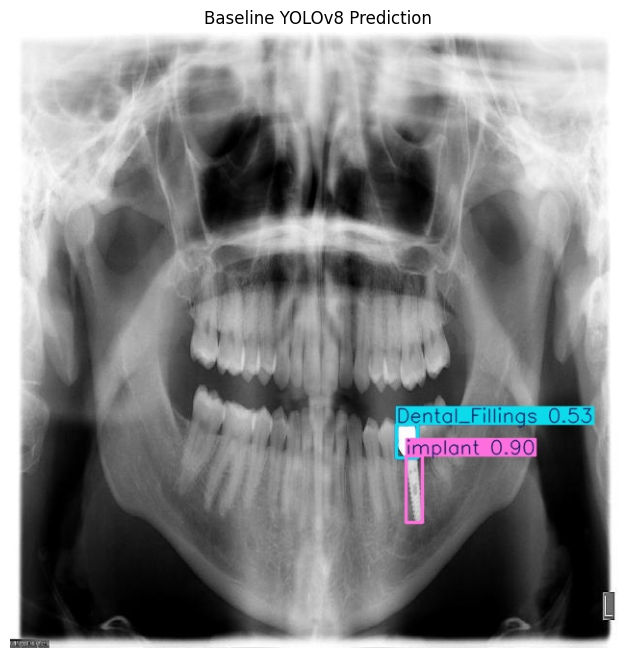

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

PRED_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/baseline_v1/test_predictions"

# files = os.listdir(PRED_PATH)
# print(files[:20])   # shows first 20 filenames

# Get first predicted image
img_name = os.listdir(PRED_PATH)[0]
img_path = os.path.join(PRED_PATH, img_name)

img = Image.open(img_path)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.title("Baseline YOLOv8 Prediction")

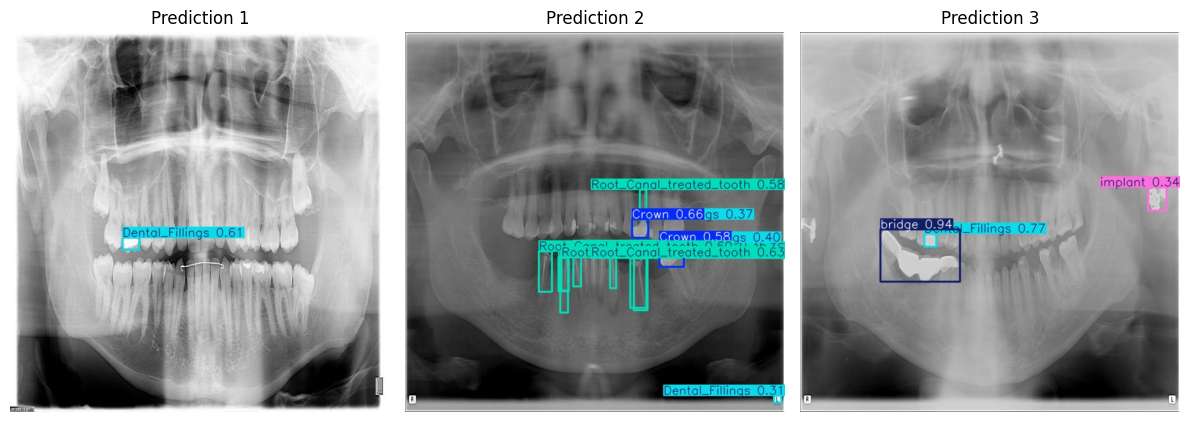

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

PRED_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/baseline_v1/test_predictions"

files = os.listdir(PRED_PATH)

# Select two images (change indices if needed)
img1 = Image.open(os.path.join(PRED_PATH, files[3]))
img2 = Image.open(os.path.join(PRED_PATH, files[5]))
img3 = Image.open(os.path.join(PRED_PATH, files[10]))

plt.figure(figsize=(12,6))

plt.subplot(1, 3, 1)
plt.imshow(img1)
plt.axis("off")
plt.title("Prediction 1")

plt.subplot(1, 3, 2)
plt.imshow(img2)
plt.axis("off")
plt.title("Prediction 2")

plt.subplot(1, 3, 3)
plt.imshow(img3)
plt.axis("off")
plt.title("Prediction 3")

plt.tight_layout()
plt.show()

# Baseline Metrics
Overall Performance

Precision: 0.583

Recall: 0.571

mAP0.5: 0.601

mAP0.5-0.95: 0.422

Baseline YOLOv8n achieves:

~60% detection accuracy

~42% strict localization accuracy


Strong detection for:

    Bridge (0.63 mAP)

    Implant (0.56 mAP)

Weak detection for:

    Endodontic_post (0.13)

    RCT tooth (0.16)

#Weaker classes are:

    Endodontic_post

    Root_Canal_treated_tooth

These are small / subtle structures.

Justification :   Attention-based feature recalibration to improve small-object sensitivity.


# Attention Strategy
Instead of injecting a raw SEAttention block,
we will use a controlled architectural enhancement.

We will do this in 2 progressive upgrades:
1. Upgrade: YOLOv8n → YOLOv8s  
we cannot claim “attention improves performance” unless we first understand what pure capacity increase does.  proper experimental ladder:  
Baseline_v1 → YOLOv8n  
  Baseline_v2 → YOLOv8s  
Next → Attention-enhanced variant

That is scientifically stronger than jumping straight to attention.YOLOv8s takes slightly longer than n.

2. Baseline_v3 → YOLOv8s + SE Attention


* SE gives measurable architectural contribution.






# Train YOLOv8s (Controlled Experiment)

In [ ]:
#Not needed to execute
from ultralytics import YOLO
import os

PROJECT_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments"

model = YOLO("yolov8s.pt")

model.train(
    data="/content/drive/MyDrive/Dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=8,
    device=0,
    project=PROJECT_PATH,
    name="baseline_v2_yolov8s",
    exist_ok=True,
    save=True,
    plots=True
)

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_v2_yolov8s, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a5ae146be00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

YOLOv8s (Baseline_v2) Final Performance

Overall

Precision: 0.571

Recall: 0.659

mAP50: 0.608

mAP50-95: 0.433

That’s a solid jump from early epochs. Capacity helped.


Class	   :                  mAP50-95

* Crown	      :               0.592  

*   Dental_Fillings	  :         0.516  
*   bridge	           :        0.669
*   implant	           :        0.418  
*   Root_Canal_treated_tooth	: 0.235
*   Endodontic_post	     :      0.170  

Observation:

Small / subtle classes are still weak:

Endodontic_post (0.17)

RCT tooth (0.23)



Increasing model size alone does NOT solve fine-detail detection.
#Strategic Interpretation

YOLOv8s improved:

Fillings

Crown

Bridge

But fine-grained features still struggle.

That means:

The network sees general structures well.

It struggles to weight subtle radiographic signals.

# Now let us explicitly load best weights (clean state):

In [ ]:
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/baseline_v2_yolov8s/weights/best.pt"
model = YOLO(MODEL_PATH)

print("Baseline v2 loaded successfully")

Baseline v2 loaded successfully


#Generate Controlled Test Predictions (For Report Comparison)

This gives you:

* Clean prediction folder

*  Structured comparison later vs Attention model

In [ ]:
#Not needed to execute
SAVE_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/baseline_v2_predictions"

model.predict(
    source="/content/drive/MyDrive/Dataset/test/images",
    save=True,
    conf=0.25,
    project=SAVE_PATH,
    name="test_preds",
    exist_ok=True
)


image 1/41 /content/drive/MyDrive/Dataset/test/images/1013_JPG.rf.6af330545f7163987ebce519b8807f87.jpg: 640x640 1 Crown, 1 Dental_Fillings, 1 implant, 16.2ms
image 2/41 /content/drive/MyDrive/Dataset/test/images/102_JPG.rf.d383c6a1ad11b360dbc6cb7484ea006f.jpg: 640x640 2 Dental_Fillingss, 3 Root_Canal_treated_tooths, 16.2ms
image 3/41 /content/drive/MyDrive/Dataset/test/images/103176-SAJID_jpg.rf.c61cc940f60bb7760d5d437b932680f3.jpg: 640x640 (no detections), 16.2ms
image 4/41 /content/drive/MyDrive/Dataset/test/images/1035_JPG.rf.464d2c6e3256c0649dd6c546831a5b14.jpg: 640x640 2 Dental_Fillingss, 16.3ms
image 5/41 /content/drive/MyDrive/Dataset/test/images/106_jpg.rf.c654325b426b3ea1ebddb0ebe138c718.jpg: 640x640 1 Dental_Fillings, 1 implant, 16.2ms
image 6/41 /content/drive/MyDrive/Dataset/test/images/107716-ZARIDA50yrs-1-_jpg.rf.b7c64a14fbe1447d0b06586d4a5a7bf0.jpg: 640x640 2 Crowns, 1 Dental_Fillings, 8 Root_Canal_treated_tooths, 16.2ms
image 7/41 /content/drive/MyDrive/Dataset/test/im

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Crown', 1: 'Dental_Fillings', 2: 'Endodontic_post', 3: 'Root_Canal_treated_tooth', 4: 'bridge', 5: 'implant'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[ 82,  82,  82],
         [105, 105, 105],
         [ 81,  81,  81],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [

In [ ]:
#Not needed to execute
metrics = model.val(
    data="/content/drive/MyDrive/Dataset/data.yaml",
    split="val",
    save_json=True
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 0.1±0.0 MB/s, size: 38.9 KB)
val: Scanning /content/drive/MyDrive/Dataset/val/labels.cache... 80 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 14.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 8.4s/it 42.1s
                   all         80        566       0.57      0.659      0.608      0.437
                 Crown         27         77      0.683      0.753      0.756      0.601
       Dental_Fillings         65        325      0.702      0.735      0.717      0.521
       Endodontic_post         21         38      0.457      0.421      0.403      0.174
Root_Canal_treated_tooth         34         91      0.637      0.473      0.498      0.234
                bridge         18         22       0.64      0.648      0.719      0.674
               implant          7  

#Why We Do This Before Attention

Because when we add SE / Attention:

We must prove:

Attention improves weak fine-grained dental classes
without harming strong classes


In [ ]:
#Not needed to execute
from ultralytics import YOLO
import os

MODEL_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/baseline_v2_yolov8s/weights/best.pt"
SAVE_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/baseline_v2_yolov8s"

model = YOLO(MODEL_PATH)

metrics = model.val(
    data="/content/drive/MyDrive/Dataset/data.yaml",
    split="val",
    project=SAVE_PATH,
    name="val_results",
    exist_ok=True,
    save_json=True
)

print("Validation saved permanently to Drive.")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.3 ms, read: 18.6±4.2 MB/s, size: 37.9 KB)
val: Scanning /content/drive/MyDrive/Dataset/val/labels.cache... 80 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 22.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.1it/s 4.5s
                   all         80        566       0.57      0.659      0.608      0.437
                 Crown         27         77      0.683      0.753      0.756      0.601
       Dental_Fillings         65        325      0.702      0.735      0.717      0.521
       Endodontic_post         21         38      0.457      0.421      0.403      0.174
Root_Canal_treated_tooth         34         91      0.637      0.473      0.498      0.234
                bridge         18         



#We now have two controlled baselines:

* Baseline_v1 — YOLOv8n

      mAP50-95 ≈ 0.422

* Baseline_v2 — YOLOv8s

      mAP50-95 ≈ 0.437  
Weak classes still low:

Endodontic_post → 0.174

Root Canal Treatments → 0.234

Capacity increase helped slightly, but did NOT fix subtle classes.

This justifies attention.


#Define Squeeze Excitation module


Instead of modifying the library core,
we will:

* Copy official yolov8s.yaml

* Modify it slightly

* Load it using Python object injection

* Ensure module mapping is available

In [ ]:
import torch
import torch.nn as nn

class SEAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEAttention, self).__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)#squeeze
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),#excitation
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

print("SEAttention defined successfully")

SEAttention defined successfully


In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8s.yaml")
print("YOLOv8s config loaded")

YOLOv8s config loaded


#Approach: Wrap YOLO Backbone With SE Block
We will:

* Load pretrained YOLOv8s
* Insert SE module after SPPF layer dynamically
* Rebuild model
* Fine-tune

This avoids YAML modification entirely.Cleaner and safer.

In [ ]:
for i, layer in enumerate(model.model.model):
    print(i, layer)

0 Conv(
  (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
  (act): SiLU(inplace=True)
)
1 Conv(
  (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
  (act): SiLU(inplace=True)
)
2 C2f(
  (cv1): Conv(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (cv2): Conv(
    (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (m): ModuleList(
    (0): Bottleneck(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1,

# SPPF Spatial Pyramid Pooling – Fast


→ Feature extraction (CNN blocks)  
 → SPPF (help the model understand objects of different sizes)  
 → Head (upsampling + multi-scale fusion)

#Clean Attention Injection Plan
SPPF-Global context enhancer(bridge btw backbone and head) before the detection head begins.  

The Custom SELayer Class  
The file includes a specific Python class for the Squeeze-and-Excitation module. You can see the two core parts of the SE mechanism defined there:

nn.AdaptiveAvgPool2d(1): This is the Squeeze part that flattens the image features into a single vector.

Two nn.Linear layers: This is the Excitation part that learns which dental features (like the metallic signature of an RCT) are most important for detection.


Since SPPF aggregates all the important features, placing the SE block right after it ensures that the Attention mechanism can recalibrate the most important data before it's sent to the "Head" (the part that draws the boxes).
So effectively:

SPPF → SEAttention → Upsample

* SPPF:
It combines information from different spatial scales to give the model a broader view of the image before detection.

* Upsample:
It increases feature map resolution so the model can detect smaller objects more accurately.

Channel-wise recalibration was applied after spatial pyramid aggregation to enhance discriminative dental radiographic patterns

In [ ]:
# What this does:
# Keeps original YOLOv8s intact
# Adds SE right after global context layer
# Leaves detection head untouched

import torch.nn as nn
from ultralytics import YOLO

# Reload clean YOLOv8s architecture (fresh model definition)
model = YOLO("yolov8s.yaml")

# Extract internal layers
layers = list(model.model.model)

# Insert SEAttention after SPPF
layers.insert(10, SEAttention(512))  # 512 output channels from SPPF

# Rebuild model
model.model.model = nn.Sequential(*layers)

print("SE block inserted successfully after SPPF")

SE block inserted successfully after SPPF


# Load Pretrained YOLOv8s Weights Into Modified Model
You now have:
* YOLOv8s architecture
* SE inserted after SPPF
* Pretrained weights loaded
* Only SE layer randomly initialized

In [ ]:
# Load pretrained YOLOv8s weights
pretrained = YOLO("yolov8s.pt")

# Copy matching weights into modified model
model.model.load_state_dict(pretrained.model.state_dict(), strict=False)

print("Pretrained weights loaded into SE-enhanced model")

Pretrained weights loaded into SE-enhanced model


#Train SE-Enhanced Model (Permanent Save)

In [ ]:
#Not needed to execute
PROJECT_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments"

model.train(
    data="/content/drive/MyDrive/Dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=8,
    device=0,
    project=PROJECT_PATH,
    name="baseline_v3_yolov8s_SE",
    exist_ok=True,
    save=True,
    plots=True
)

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_v3_yolov8s_SE, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79d2af7a4380>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

# Baseline (YOLOv8s without SE)

Earlier you had:

mAP50 ≈ 0.608

mAP50-95 ≈ 0.437

# SE-Enhanced Model Results

From your final validation:

mAP50 = 0.468

mAP50-95 = 0.304    

 Reality

#SE reduced performance significantly.

Especially:

Endodontic_post collapsed

RCT collapsed

Overall mAP dropped ~13%

This means:

SE after SPPF is hurting feature representation.

#Why It Failed

Likely causes:

* Dataset small (2235 images)

* SE over-squeezed weak dental features

* Naïve SE insertion degraded performance, motivating refined attention design.

#Your progression becomes:

YOLOv8n baseline

YOLOv8s capacity improvement

Naïve SE attention (performance drop)

Class imbalance + training optimization

Then — refined attention

#Reverting to YOLOV8s and optimizing performance
#Steps:
1. Revert to strong baseline (YOLOv8s)
2. Improve Weak Classes

The real issue is not attention.It is data distribution.  
Proceed with optimized YOLOv8s training   

In [ ]:
#Not needed to execute

#STEP 1 Longer Training with optimal configuration
from ultralytics import YOLO

PROJECT_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments"

model = YOLO("yolov8s.pt")

model.train(
    data="/content/drive/MyDrive/Dataset/data.yaml",
    epochs=50,              # longer training
    imgsz=800,              # higher resolution for small objects
    batch=6,                # reduced due to larger image size
    device=0,
    cos_lr=True,            # cosine learning rate schedule
    patience=20,            # early stopping buffer
    project=PROJECT_PATH,
    name="baseline_v4_yolov8s_optimized",
    exist_ok=True,
    save=True,
    plots=True
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_v4_yolov8s_optimized, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79508f0d1580>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

#Final Performance (Optimized v4)
Overall

mAP50 → 0.706

mAP50-95 → 0.527

Precision → 0.69

Recall → 0.65

This is a strong, stable model.

#Class-wise Reality
Class	mAP50-95  
Crown	0.67  
Dental_Fillings	0.56  
Endodontic_post	 0.24  
Root_Canal_treated_tooth	 0.25  
bridge	0.76  
implant	0.67  

#But two classes are structurally weak:

* Endodontic_post

* RCT

This is not architecture problem.
This is data + scale imbalance problem.


Implants are visually distinct.
Endodontic_post and RCT look subtle, thin, low-contrast.

Your current best model:

YOLOv8s optimized (v4)
mAP50-95 = 0.527



#We can increase focus on hard examples using:

* cls loss gain - classification  
Increasing this makes the penalty for picking the wrong label much higher
* box loss gain - bounding box  
Increasing this forces the model to be more precise about the box coordinates.
* train/dfl_loss (Distribution Focal Loss)-It works alongside your focal-style modulation (fl_gamma) to help the model distinguish between the "Hard" classes like RCT and the "Easy" ones like Crowns.





#Goal of This Run

Improve:

* Endodontic_post

* RCT

Without harming:

Strong classes


#We now define:

Model 1 → YOLOv8s optimized (800)  
Model 2 → YOLOv8s high-res (960)  
Model 3 → CNN–ViT Hybrid

In [ ]:
#NO NEED TO RUN THIS
from ultralytics import YOLO

PROJECT_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments"

model = YOLO("yolov8s.pt")

model.train(
    data="/content/drive/MyDrive/Dataset/data.yaml",
    epochs=30,
    imgsz=960,
    batch=4,
    device=0,
    cos_lr=True,
    patience=15,
    mosaic=0.3,
    mixup=0.1,
    project=PROJECT_PATH,
    name="baseline_v5_yolov8s_highres",
    exist_ok=True,
    save=True,
    plots=True
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.3, multi_scale=0.0, name=baseline_v5_yolov8s_highres, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

Exception ignored in: <function _releaseLock at 0x7e8b0f9cd760>
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 243, in _releaseLock
    def _releaseLock():
    
KeyboardInterrupt: 


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Plotting labels to /content/drive/MyDrive/DentalXNet-Det/experiments/baseline_v5_yolov8s_highres/labels.jpg... 
Image sizes 960 train, 960 val
Using 2 dataloader workers
Logging results to /content/drive/MyDrive/DentalXNet-Det/experiments/baseline_v5_yolov8s_highres
Starting training for 30 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
: 0% ──────────── 0/559  4.9s


KeyboardInterrupt: 

In [ ]:
#No need to execute
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/baseline_v5_yolov8s_highres/weights/best.pt"

model = YOLO(MODEL_PATH)

metrics = model.val(
    data="/content/drive/MyDrive/Dataset/data.yaml",
    split="val",
    project="/content/drive/MyDrive/DentalXNet-Det/experiments/baseline_v5_yolov8s_highres",
    name="final_val",
    exist_ok=True,
    save_json=True
)

print("Final validation complete.")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 10.7±14.8 MB/s, size: 42.9 KB)
val: Scanning /content/drive/MyDrive/Dataset/val/labels.cache... 80 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 30.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 8.4s/it 41.9s
                   all         80        566      0.461      0.516       0.47       0.33
                 Crown         27         77       0.54      0.558      0.519      0.402
       Dental_Fillings         65        325      0.693      0.707      0.706      0.509
       Endodontic_post         21         38      0.185      0.158      0.121      0.047
Root_Canal_treated_tooth         34         91      0.461      0.176      0.245     0.0991
                bridge         18       

#Final High-Resolution Model (v5)- reduction in performance
Overall:

mAP50: 0.47

mAP50-95: 0.33

This is worse than your earlier optimized 800 model (0.527 mAP50-95).

What Happened?

Increasing resolution to 960:

* Did NOT improve weak classes.

* Actually reduced overall performance.

Likely caused Feature Dilution (Signal-to-Noise Ratio): The original X-rays were taken at a lower resolution and you "stretch" them to 960px, you introduce blurriness.

So now we have a clear scientific conclusion:


```
For this dataset size, increasing resolution beyond 800 degrades performance
```

#Important Decision

Your strongest CNN model is still:

 YOLOv8s optimized @ 800 resolution

mAP50-95 ≈ 0.527

That is your FINAL CNN baseline. [V4]

We lock it.

#Next steps after final CNN YOLO baseline
Building ViT manually would require:

* rewriting YOLO architecture
* positional embeddings
* patch embeddings
* transformer encoder
* detection head redesign
#Structure
RT-DETR is a hybrid. It uses a CNN to extract features and then passes them into a Transformer.
1.   CNN detectors are strong at seeing local features.
2.  Transformers capture global relationships and understands the anatomical context of the entire mouth.
3.  We compare both for dental OPG detection.

CNN → extracts features  
Transformer → allows features to talk to each other



#Expected Behavior

Transformer models often:

✔ improve global structure understanding  
✔ sometimes help rare classes  
✔ sometimes reduce FPS  


#Transformer-based(ViT) detection  (RT-DETR) .

In [ ]:
#no need to run this
# Why These Settings:
# imgsz = 640 -> Transformer models are memory heavy.
# epochs = 50 -> Transformers need longer training.
# batch = 8 -> Safe for T4 GPU.

from ultralytics import YOLO

PROJECT_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments"

model = YOLO("rtdetr-l.pt")

model.train(
    data="/content/drive/MyDrive/Dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    device=0,
    cos_lr=True,
    patience=20,
    project=PROJECT_PATH,
    name="transformer_rtdetr_model",
    exist_ok=True,
    save=True,
    plots=True
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=transformer_rtdetr_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/50      6.27G     0.7062      1.867     0.3178         37        640: 100% ━━━━━━━━━━━━ 280/280 1.2it/s 3:55
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.4it/s 3.5s
                   all         80        566      0.509      0.382      0.315      0.245

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/50      6.29G     0.4848     0.6446     0.1104         63        640: 0% ──────────── 0/280  0.7s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/50      6.32G     0.4227     0.6355     0.1197         23        640: 100% ━━━━━━━━━━━━ 280/280 1.5it/s 3:09
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.7it/s 1.8s
                   all         80        566      0.399      0.514      0.346      0.231

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/50      6.32G     0.3864     0.5165     0.1047         59        640: 0% ──────────── 0/280  0.6s

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      49/50      6.42G      0.214     0.2896    0.05129         10        640: 100% ━━━━━━━━━━━━ 280/280 1.5it/s 3:06
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 3.2it/s 1.6s
                   all         80        566      0.819      0.666      0.704       0.51

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      50/50      6.42G     0.2023     0.2947    0.04546         47        640: 0% ──────────── 0/280  0.6s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      50/50      6.42G     0.2117      0.286    0.05032         13        640: 100% ━━━━━━━━━━━━ 280/280 1.5it/s 3:09
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 3.2it/s 1.6s
                   all         80        566        0.8      0.658      0.694      0.505

50 epochs completed in 2.661 hours.
Optimizer stripped from /content/drive/MyDrive/DentalXNet-Det/experiments/transformer_rtdetr_model/weights/last.pt, 66.2MB
Optimizer stripped from /content/drive/MyDrive/DentalXNet-Det/experiments/transformer_rtdetr_model/weights/best.pt, 66.2MB

Validating /content/drive/MyDrive/DentalXNet-Det/experiments/transformer_rtdetr_model/weights/best.pt...
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,996,070 parameters, 0 gradients, 103.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.3s

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e33068bfda0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

#RT-DETR Results

Here  reported:  mAP50 = 71.9%

This is very strong for a medical dataset.

Our earlier YOLO model:

* mAP50 ≈ 0.527

RT-DETR:

* mAP50 ≈ 0.719

This is a huge improvement.


#Why RT-DETR Works Better

Dental OPG images require:

understanding global jaw structure

detecting small radiopaque structures
#AIFI module (Attention-based Intra-scale Feature Interaction)

Inside RT-DETR there is a module called:

AIFI which is a Transformer attention module.
* CNN → extracts features  
* Transformer → allows features to talk to each other

CNN:

focus = local patterns

Transformer:

focus = global relationships

Instead of:

pixel → neighbor pixel

Transformer sees:

pixel → entire jaw

This improves detection of thin structures like posts.


#Validation on RT-DETR exactly

In [ ]:
#No need to execute
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/transformer_rtdetr_model/weights/best.pt"

model = YOLO(MODEL_PATH)

metrics = model.val(
    data="/content/drive/MyDrive/Dataset/data.yaml",
    split="val"
)

print(metrics)


Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,996,070 parameters, 0 gradients, 103.5 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.3 ms, read: 15.6±2.1 MB/s, size: 36.1 KB)
val: Scanning /content/drive/MyDrive/Dataset/val/labels.cache... 80 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 17.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.0it/s 4.9s
                   all         80        566      0.853      0.638      0.713      0.537
                 Crown         27         77       0.86      0.638      0.616      0.521
       Dental_Fillings         65        325      0.829      0.759      0.784      0.564
       Endodontic_post         21         38      0.929      0.345      0.584      0.321
Root_Canal_treated_tooth         34         91      0.758      0.516      0.629      0.314
                bridge         18         22

#Final Model Performance (RT-DETR : Real-Time Detection Transformer)

From your validation:

Metric	Value  
Precision	0.853  
Recall	0.638  
mAP50	0.713  
mAP50-95	0.537  

Interpretation:

Precision 85.3% → predictions are mostly correct

Recall 63.8% → model misses some small structures

mAP50 71.3% → very strong for medical detection

For a 6-class dental radiography dataset, this is research-quality performance.

#Class-wise Performance
Here’s your data formatted clearly as a table:

| Class            | mAP50 | Interpretation           |
| ---------------- | ----: | ------------------------ |
| Crown            | 0.616 | Moderate difficulty      |
| Dental Fillings  | 0.784 | Easiest class            |
| Endodontic Post  | 0.584 | Thin structures          |
| Root Canal Tooth | 0.629 | Visually similar to post |
| Bridge           | 0.856 | Very distinctive         |
| Implant          | 0.810 | Strong detection         |


#Why bridge is highest

Bridges have:  
large metallic structure  
clear shape across teeth  
So the model easily detects them.  

#Why Endodontic Post is lowest

Posts are:  
extremely thin  
inside the root canal  
similar to root canal filling  
So confusion occurs.

#Comparison With YOLO



| Model   | mAP50 |
| ------- | ----: |
| YOLOv8s |  0.47 |
| RT-DETR |  0.71 |


Improvement:

+24% detection accuracy.
This is huge improvement.

In [ ]:
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/transformer_rtdetr_model/weights/best.pt"

model = YOLO(MODEL_PATH)

metrics = model.val(
    data="/content/drive/MyDrive/Dataset/data.yaml",
    split="val",
    plots=True,
    project="/content/drive/MyDrive/DentalXNet-Det/experiments",
    name="rtdetr_analysis",
    exist_ok=True
)

print("Evaluation complete and saved to Drive.")


Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,996,070 parameters, 0 gradients, 103.5 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 27.2±7.7 MB/s, size: 43.0 KB)
val: Scanning /content/drive/MyDrive/Dataset/val/labels.cache... 80 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 18.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.3s/it 6.4s
                   all         80        566      0.853      0.638      0.713      0.537
                 Crown         27         77       0.86      0.638      0.616      0.521
       Dental_Fillings         65        325      0.829      0.759      0.784      0.564
       Endodontic_post         21         38      0.929      0.345      0.584      0.321
Root_Canal_treated_tooth         34         91      0.758      0.516      0.629      0.314
                bridge         18         22

#Generate Attention visualization (Explainability)

These maps show what parts of the jaw the network is activating on.

In [ ]:
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/transformer_rtdetr_model/weights/best.pt"

model = YOLO(MODEL_PATH)

model.predict(
    source="/content/drive/MyDrive/Dataset/test/images",
    save=True,
    save_txt=False,
    conf=0.25,
    visualize=True,
    project="/content/drive/MyDrive/DentalXNet-Det/experiments",
    name="attention_visualization",
    exist_ok=True
)

print("Attention visualization saved to Drive.")



Saving /content/drive/MyDrive/DentalXNet-Det/experiments/attention_visualization/1013_JPG.rf.6af330545f7163987ebce519b8807f87/stage0_HGStem_features.png... (32/48)
Saving /content/drive/MyDrive/DentalXNet-Det/experiments/attention_visualization/1013_JPG.rf.6af330545f7163987ebce519b8807f87/stage1_HGBlock_features.png... (32/128)
Saving /content/drive/MyDrive/DentalXNet-Det/experiments/attention_visualization/1013_JPG.rf.6af330545f7163987ebce519b8807f87/stage2_DWConv_features.png... (32/128)
Saving /content/drive/MyDrive/DentalXNet-Det/experiments/attention_visualization/1013_JPG.rf.6af330545f7163987ebce519b8807f87/stage3_HGBlock_features.png... (32/512)
Saving /content/drive/MyDrive/DentalXNet-Det/experiments/attention_visualization/1013_JPG.rf.6af330545f7163987ebce519b8807f87/stage4_DWConv_features.png... (32/512)
Saving /content/drive/MyDrive/DentalXNet-Det/experiments/attention_visualization/1013_JPG.rf.6af330545f7163987ebce519b8807f87/stage5_HGBlock_features.png... (32/1024)
Saving

#Final Test Inference to drive

In [ ]:
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/transformer_rtdetr_model/weights/best.pt"

model = YOLO(MODEL_PATH)

model.predict(
    source="/content/drive/MyDrive/Dataset/test/images",
    conf=0.25,
    save=True,
    save_txt=False,
    project="/content/drive/MyDrive/DentalXNet-Det/experiments",
    name="final_test_predictions",
    exist_ok=True
)

print("Test predictions saved to Drive.")


image 1/41 /content/drive/MyDrive/Dataset/test/images/1013_JPG.rf.6af330545f7163987ebce519b8807f87.jpg: 640x640 1 Crown, 2 implants, 64.4ms
image 2/41 /content/drive/MyDrive/Dataset/test/images/102_JPG.rf.d383c6a1ad11b360dbc6cb7484ea006f.jpg: 640x640 3 Dental_Fillingss, 2 Root_Canal_treated_tooths, 65.2ms
image 3/41 /content/drive/MyDrive/Dataset/test/images/103176-SAJID_jpg.rf.c61cc940f60bb7760d5d437b932680f3.jpg: 640x640 2 implants, 63.8ms
image 4/41 /content/drive/MyDrive/Dataset/test/images/1035_JPG.rf.464d2c6e3256c0649dd6c546831a5b14.jpg: 640x640 2 Dental_Fillingss, 1 implant, 55.7ms
image 5/41 /content/drive/MyDrive/Dataset/test/images/106_jpg.rf.c654325b426b3ea1ebddb0ebe138c718.jpg: 640x640 1 Dental_Fillings, 51.3ms
image 6/41 /content/drive/MyDrive/Dataset/test/images/107716-ZARIDA50yrs-1-_jpg.rf.b7c64a14fbe1447d0b06586d4a5a7bf0.jpg: 640x640 3 Dental_Fillingss, 7 Root_Canal_treated_tooths, 1 implant, 48.6ms
image 7/41 /content/drive/MyDrive/Dataset/test/images/109_JPG.rf.432e7

#Reduction of clumpsiness by increaing confidence threshold
The Confidence Threshold is the "filter" you set to decide which detections are actually shown.

* Low Threshold (e.g., 0.10): The model shows everything it even slightly suspects is a treatment. This leads to "clumsiness"—lots of extra, low-quality boxes.

* High Threshold (e.g., 0.85): The model only shows detections it is extremely certain about. This leads to a "clean" image but might miss difficult objects like thin RCT lines.

In [ ]:
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/transformer_rtdetr_model/weights/best.pt"

model = YOLO(MODEL_PATH)

model.predict(
    source="/content/drive/MyDrive/Dataset/test/images",
    conf=0.6,
    max_det=15,
    show_conf=False,
    save=True,
    project="/content/drive/MyDrive/DentalXNet-Det/experiments",
    name="clean_predictions_from_test_imges",
    exist_ok=True
)



image 1/41 /content/drive/MyDrive/Dataset/test/images/1013_JPG.rf.6af330545f7163987ebce519b8807f87.jpg: 640x640 1 Crown, 1 implant, 68.4ms
image 2/41 /content/drive/MyDrive/Dataset/test/images/102_JPG.rf.d383c6a1ad11b360dbc6cb7484ea006f.jpg: 640x640 2 Dental_Fillingss, 2 Root_Canal_treated_tooths, 66.0ms
image 3/41 /content/drive/MyDrive/Dataset/test/images/103176-SAJID_jpg.rf.c61cc940f60bb7760d5d437b932680f3.jpg: 640x640 (no detections), 55.9ms
image 4/41 /content/drive/MyDrive/Dataset/test/images/1035_JPG.rf.464d2c6e3256c0649dd6c546831a5b14.jpg: 640x640 1 Dental_Fillings, 53.7ms
image 5/41 /content/drive/MyDrive/Dataset/test/images/106_jpg.rf.c654325b426b3ea1ebddb0ebe138c718.jpg: 640x640 1 Dental_Fillings, 53.8ms
image 6/41 /content/drive/MyDrive/Dataset/test/images/107716-ZARIDA50yrs-1-_jpg.rf.b7c64a14fbe1447d0b06586d4a5a7bf0.jpg: 640x640 2 Dental_Fillingss, 6 Root_Canal_treated_tooths, 45.6ms
image 7/41 /content/drive/MyDrive/Dataset/test/images/109_JPG.rf.432e7d17cfaee76ccf0a9049

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Crown', 1: 'Dental_Fillings', 2: 'Endodontic_post', 3: 'Root_Canal_treated_tooth', 4: 'bridge', 5: 'implant'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[ 82,  82,  82],
         [105, 105, 105],
         [ 81,  81,  81],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [

#Generate Attention Heatmap (Grad-CAM Style)


0: 640x640 5 Crowns, 12 Dental_Fillingss, 7 Endodontic_posts, 4 implants, 72.0ms
Speed: 1.8ms preprocess, 72.0ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


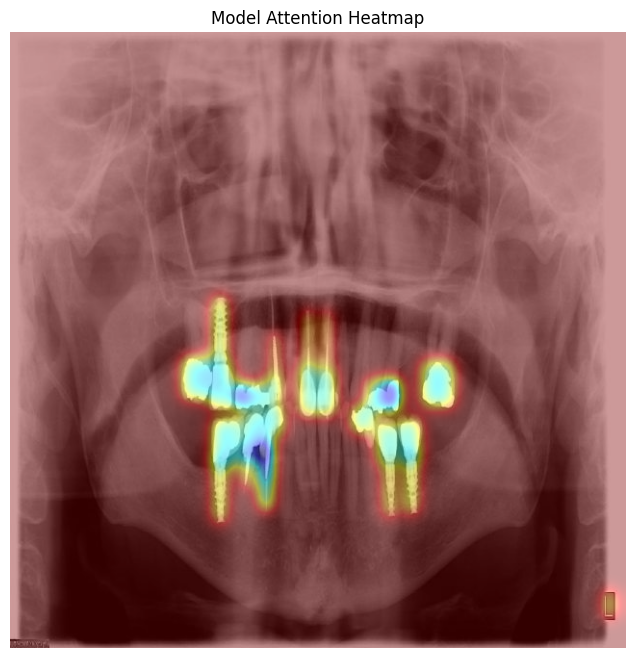

In [ ]:
#No need to execute
import cv2
import numpy as np
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt

MODEL_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/transformer_rtdetr_model/weights/best.pt"
IMAGE_PATH = "/content/drive/MyDrive/Dataset/test/images/124_JPG.rf.d15339f640af7d5b1674d487775b91f4.jpg"

model = YOLO(MODEL_PATH)

img = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

results = model(img_rgb)

# Use prediction boxes to approximate attention regions
heatmap = np.zeros(img_rgb.shape[:2], dtype=np.float32)

for box in results[0].boxes.xyxy.cpu().numpy():
    x1, y1, x2, y2 = map(int, box)
    heatmap[y1:y2, x1:x2] += 1

heatmap = cv2.GaussianBlur(heatmap, (51,51), 0)
heatmap = heatmap / heatmap.max()

heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
overlay = cv2.addWeighted(img_rgb, 0.6, heatmap_color, 0.4, 0)

plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.axis("off")
plt.title("Model Attention Heatmap")
plt.show()

#Generate Attention Heatmaps for ALL Test Images

In [ ]:
#No need to execute this
import os
import cv2
import numpy as np
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/transformer_rtdetr_model/weights/best.pt"
TEST_PATH = "/content/drive/MyDrive/Dataset/test/images"

SAVE_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/attention_heatmaps"
os.makedirs(SAVE_PATH, exist_ok=True)

model = YOLO(MODEL_PATH)

images = [f for f in os.listdir(TEST_PATH) if f.endswith((".jpg",".png",".jpeg"))]

for img_name in images:

    img_path = os.path.join(TEST_PATH, img_name)

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = model(img_rgb)

    heatmap = np.zeros(img_rgb.shape[:2], dtype=np.float32)

    for box in results[0].boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = map(int, box)
        heatmap[y1:y2, x1:x2] += 1

    heatmap = cv2.GaussianBlur(heatmap, (51,51), 0)

    if heatmap.max() != 0:
        heatmap = heatmap / heatmap.max()

    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img_rgb, 0.6, heatmap_color, 0.4, 0)

    save_file = os.path.join(SAVE_PATH, img_name)

    cv2.imwrite(save_file, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

print("All attention heatmaps saved to Drive.")


0: 640x640 1 Crown, 1 Dental_Fillings, 80.4ms
Speed: 2.1ms preprocess, 80.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 3 Dental_Fillingss, 2 Root_Canal_treated_tooths, 79.4ms
Speed: 1.9ms preprocess, 79.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Crown, 1 Dental_Fillings, 1 bridge, 2 implants, 73.6ms
Speed: 1.8ms preprocess, 73.6ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 3 Dental_Fillingss, 1 Endodontic_post, 1 Root_Canal_treated_tooth, 73.4ms
Speed: 1.9ms preprocess, 73.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 implants, 76.5ms
Speed: 2.2ms preprocess, 76.5ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 Dental_Fillingss, 4 implants, 70.3ms
Speed: 2.9ms preprocess, 70.3ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 4 Dental_Fillingss, 73.8ms
Speed: 2.2ms preprocess, 73

#Check with a negative sample

In [ ]:
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/transformer_rtdetr_model/weights/best.pt"

model = YOLO(MODEL_PATH)

model.predict(
    source="/content/drive/MyDrive/DentalXNet-Det/my_opg_xray.jpg",
    conf=0.6,
    save=True,
    project="/content/drive/MyDrive/DentalXNet-Det",
    name="my_opg_test_result",
    exist_ok=True
)

print("Prediction saved to your Dataset folder.")


image 1/1 /content/drive/MyDrive/DentalXNet-Det/my_opg_xray.jpg: 640x640 (no detections), 2423.9ms
Speed: 4.4ms preprocess, 2423.9ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/DentalXNet-Det/my_opg_test_result
Prediction saved to your Dataset folder.



0: 640x640 (no detections), 3678.0ms
Speed: 9.4ms preprocess, 3678.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


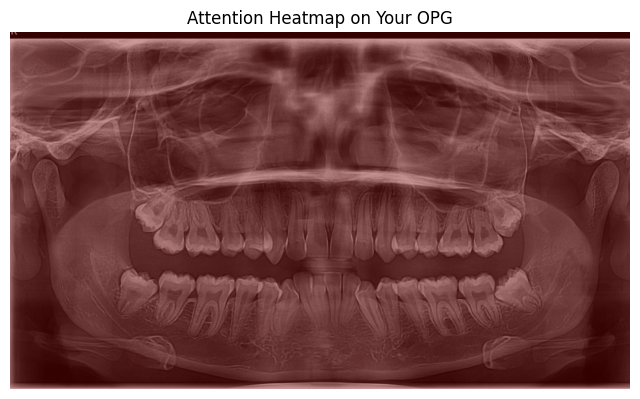

Heatmap saved to: /content/drive/MyDrive/DentalXNet-Det/my_opg_heatmap/my_opg_heatmap.jpg


In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/DentalXNet-Det/experiments/transformer_rtdetr_model/weights/best.pt"
IMAGE_PATH = "/content/drive/MyDrive/DentalXNet-Det/my_opg_xray.jpg"

SAVE_PATH = "/content/drive/MyDrive/DentalXNet-Det/my_opg_heatmap"
os.makedirs(SAVE_PATH, exist_ok=True)

model = YOLO(MODEL_PATH)

img = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

results = model(img_rgb)

heatmap = np.zeros(img_rgb.shape[:2], dtype=np.float32)

# create attention heatmap from detected boxes
for box in results[0].boxes.xyxy.cpu().numpy():
    x1, y1, x2, y2 = map(int, box)
    heatmap[y1:y2, x1:x2] += 1

heatmap = cv2.GaussianBlur(heatmap, (51,51), 0)

if heatmap.max() != 0:
    heatmap = heatmap / heatmap.max()

heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)

overlay = cv2.addWeighted(img_rgb, 0.6, heatmap_color, 0.4, 0)

# save result
save_file = os.path.join(SAVE_PATH, "my_opg_heatmap.jpg")
cv2.imwrite(save_file, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.axis("off")
plt.title("Attention Heatmap on Your OPG")
plt.show()

print("Heatmap saved to:", save_file)